# OTTER Paper Plots

In this (rather long) tutorial we go through creating most of the figures in the OTTER paper using the OTTER python API. 

_Note:_ This tutorial was created with the OTTER dataset as of August, 2025. Rerunning this tutorial with future datasets may produce different results than the plots shown in the paper. To exactly reproduce those plots please use a backup copy of the dataset from that time.

## Some Setup

In [1]:
# imports we will use throughout
# if you get an ImportError you may need to install something

import os
import io
import warnings
from copy import deepcopy

import otter # of course!
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import scipy

from astropy import units as u, constants as c
from astropy.coordinates import SkyCoord
from astropy.time import Time

import astropy.cosmology.units as cu
from astropy.cosmology import Planck18 as cosmo

import matplotlib as mpl
import cmasher as cmr

from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator

In [2]:
# connect to the OTTER server
db = otter.Otter()

Attempting to login to https://otter.idies.jhu.edu/api with the following credentials:
username: user-guest
password: test


In [3]:
# create a directory to save the figures to, if it doesn't exist
plotdir = os.path.join(os.getcwd(), "otter_paper_plots") # change this if you want the figures to go somewhere else
if not os.path.exists(plotdir):
    os.makedirs(plotdir)

# and define some keyword arguments for saving so the figures look nice :)
plot_save_kwargs = dict(
    bbox_inches="tight",
    dpi = 200
)

# and a function to save the figures to a consistent place
def savefig(fig, figname, plotdir=plotdir, plot_save_kwargs=plot_save_kwargs):
    fig.savefig(
        os.path.join(plotdir, figname),
        **plot_save_kwargs
    )

## Sections 3 and 4: Summary Plots of the Current Dataset

### Figure 3: Maximum Confidence Flag
This plot is created by pulling the maximum classification flag associated with each transient in otter. This requires pulling it out of the default classification stored in a transient object. Luckily, there's a method built into the `Transient` class for this!

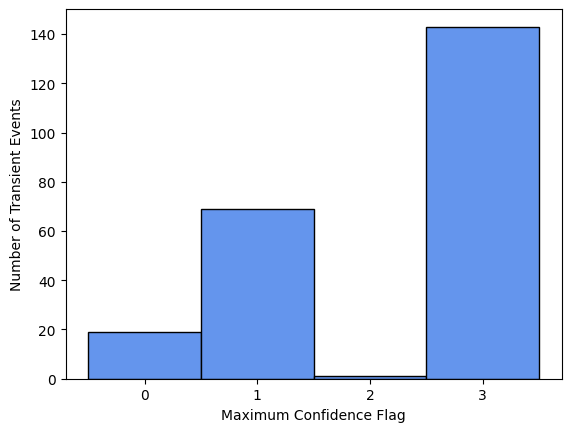

In [4]:
# get all the metadata associated with each transient
meta = db.get_meta()

# meta is a list of Transient objects so we need to loop over them to get the class
class_flag = []
for transient in meta:
    class_, conf_flag, ref_list = transient.get_classification()

    # the only thing we really need is the conf_flag for this plot
    class_flag.append(conf_flag)

# now we can create the plot!
fig, ax = plt.subplots()
ax.hist(
    class_flag,
    facecolor = "cornflowerblue",
    edgecolor = "k",
    bins = 4,
    range = (0,4),
    align = "left"
)
ax.set_xticks([0, 1, 2, 3], [0, 1, 2, 3])
ax.set_ylabel("Number of Transient Events")
ax.set_xlabel("Maximum Confidence Flag")
savefig(fig, "max-conf-flag-hist.png")

### Figure 7 (And Figure 16 in Appendix C)

These are histograms showing the discovery regime of different TDEs. This information is stored in the classification dictionary in the metadata.

In [5]:
# get all the metadata associated with each transient
meta = db.get_meta()

# similarly, iterate over the metadata and pull out the "discovery_method"
discovery_types = []
discovery_date = []
names = []
for transient in meta:
    class_info = transient["classification"]
    if "discovery_method" in class_info:
        disc_method = class_info["discovery_method"]
    else:
        # Since the discovery_method is not a *required* key, some transient don't have it
        # for these, we use some other logic
        if "VAST" in transient.default_name or "VT" in transient.default_name:
            # these are radio discovered
            disc_method = "radio"
        elif transient.default_name in {"2019azh", "2020vdq", "2018cqh"}:
            disc_method = "uvoir"
        else:
            # a catch-all in case the dataset has changed
            warn(f"{transient.default_name} does not have a known discovery method! Skipping!")
            continue

    # then, we also need to pull out a discovery year
    # for archival searches we use the date of publication
    this_dd = transient.get_discovery_date()

    if this_dd is None and any(["WTP" in n['value'] for n in transient['name/alias']]):
        this_dd = Time("2024-02-01", format="iso")

    if this_dd is None and any(["VT" in n['value'] for n in transient['name/alias']]):
        this_dd = Time("2025-04-01", format="iso")

    if this_dd is None and any(["VAST" in n['value'] for n in transient['name/alias']]):
        this_dd = Time("2024-10-01", format="iso")
    
    discovery_date.append(this_dd)
    discovery_types.append(disc_method)
    names.append(transient.default_name)

[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019] [ 60  70  80  90 100 110 120 130 140 150 160 170 180 190 200 210 220 230
 240 250]


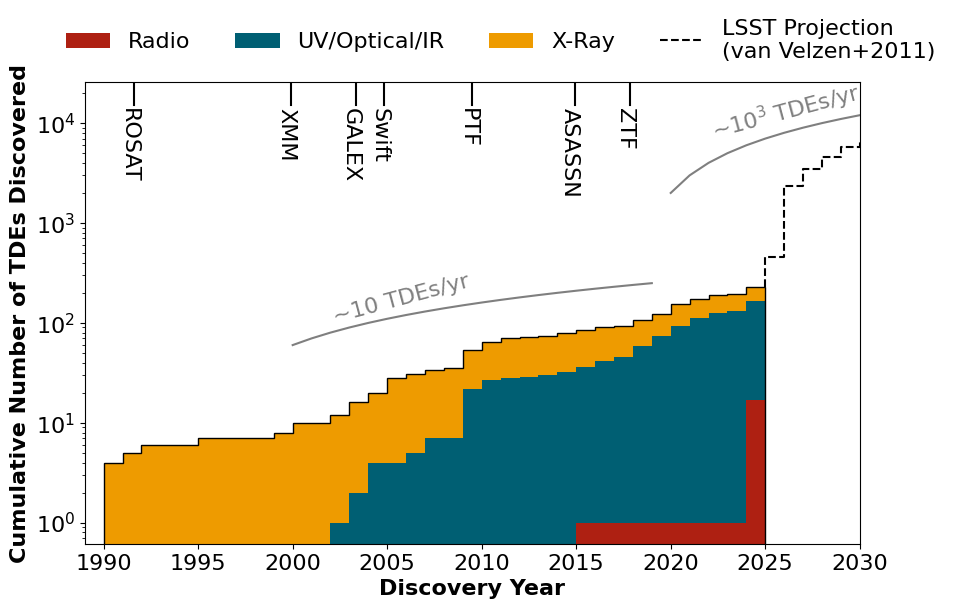

In [6]:
# now that we have the discovery year and wavelength regime we can create the plot!

cumulative = True # toggle this depending on if you want a cumulative version of the histogram

fig, ax = plt.subplots(figsize=(10,6))

rawdf = pd.DataFrame({'tde': names, 'discovery_method': discovery_types, 'discovery_date': discovery_date})
df = deepcopy(rawdf)
df = df[~pd.isna(df.discovery_date)]
df.discovery_method = df.discovery_method.replace('radio', 'Radio')
df.discovery_method = df.discovery_method.replace('xray', 'X-Ray')
df.discovery_method = df.discovery_method.replace('uvoir', 'UV/Optical/IR')

df['discovery_year'] = [int(np.floor(d.decimalyear)) for d in df.discovery_date]

n = df.discovery_year.max()-df.discovery_year.min()
bottom = np.zeros(n)

all_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
cs = ["#AE2012", "#005F73", "#EE9B00"] #[all_colors[1], all_colors[5], all_colors[8]]
# labels, years 
labels, years = np.array([(y,g.discovery_year.values) for y,g in df.groupby('discovery_method')], dtype="object").T

ax.hist(years, label=labels, bins=n, stacked=True, color=cs, cumulative=cumulative)
n, bins, _ = ax.hist(df.discovery_year, bins=n, stacked=True, histtype='step', edgecolor='k', cumulative=cumulative)

if cumulative:
    ax.set_ylabel('Cumulative Number of TDEs Discovered', fontsize=16, fontweight="semibold")
else:
    ax.set_ylabel('Number of TDEs Discovered', fontsize=16, fontweight="semibold")
ax.set_xlabel('Discovery Year', fontsize=16, fontweight="semibold")

lsst_years = list(range(2026, 2035))
lsst_n = n[-1] + np.linspace(1000, 10000, len(lsst_years))

lsst_years_plot = [2025,2026] + lsst_years
lsst_n_plot = [n[-1], 2*n[-1]] + list(lsst_n)

lsst_hist_kwargs = dict(color='k', linestyle='--', where="pre", label='LSST Projection\n(van Velzen+2011)')
if cumulative:
    ax.step(lsst_years_plot, lsst_n_plot, **lsst_hist_kwargs)
else:
    ax.step(lsst_years_plot, [0]+[1e3]*(len(lsst_years_plot)-1), **lsst_hist_kwargs)
    
if cumulative:
    # 10 tdes/yr
    years = list(range(2000, 2020))
    ten_per_year = 60 + np.array(list(range(0, 10*len(years), 10)))
    print(years, ten_per_year)
    ax.plot(years, ten_per_year, color='k', alpha=0.5)
    ax.text(2002, 100, "~10 TDEs/yr", alpha=0.5, rotation=15, fontsize=16)
    
    # 1000 tdes/yr
    years = list(range(2020, 2035))
    thsnd_per_year = 2000 + np.array(list(range(0, 1000*len(years), 1000)))
    ax.plot(years, thsnd_per_year, color='k', alpha=0.5)
    ax.text(2022, 7000, r"~10$^3$ TDEs/yr", alpha=0.5, rotation=15, fontsize=16)

# add some vertical lines were different surveys started
surveys = ["ZTF", "ASASSN", "ROSAT", "PTF", "Swift", "XMM", "GALEX"]
start_dates = [2017+(10/12), 2014+(11/12), 1991+(7/12), 2009+(6/12), 2004+(10/12), 1999+(11/12), 2003+(4/12)]
ymin = 0.95
ymin_coord = 17*(1-ymin)*ax.get_ylim()[1]
for x, lab in zip(start_dates, surveys):
    ax.axvline(x, ymin=ymin, ymax=1, color='k', alpha=1)
    ax.text(x-0.25, ymin_coord, lab, rotation=-90, alpha=1, verticalalignment="top", horizontalalignment="center", fontsize=16)

ax.set_xlim(1989, 2030)


ax.set_yscale('log')

ax.tick_params(axis='x', labelsize=16)      # x-axis tick labels
ax.tick_params(axis='y', labelsize=16)      # y-axis tick labels

ax.legend(frameon=False, bbox_to_anchor=(-0.05,1), loc="lower left", ncols=4, fontsize=16);

if cumulative:
    savefig(fig, "tde-discovery-histogram-cumulative.png");
else:
    savefig(fig, "tde-discovery-histogram.png");
    

### Figure 8: Redshift Histogram

94.39655172413794 % of the transients in OTTER have a redshift


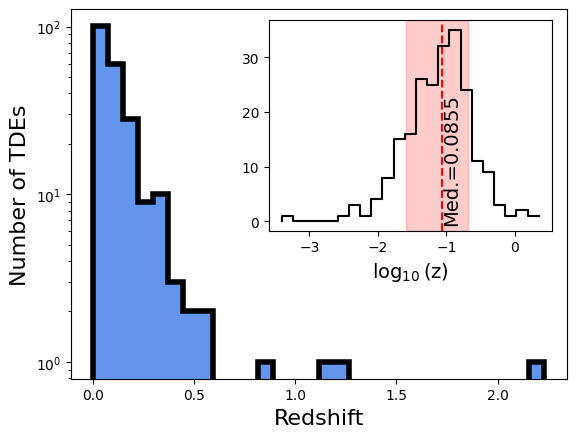

In [7]:
# get the transient meta
all_transients = db.get_meta()

# now gather the redshifts
z  = []
n_z = 0
n = len(all_transients)
for t in all_transients:
    try:
        z.append(t.get_redshift())
        n_z += 1
    except KeyError:
        continue
        
z = np.array(z).astype(float)

print(n_z/n * 100, "% of the transients in OTTER have a redshift")

# and create the figure

fig, ax1 = plt.subplots()

ax1.hist(z, lw=4, histtype="stepfilled", color="cornflowerblue", bins=30, edgecolor="k")
ax1.set_yscale("log")

ax = ax1.inset_axes([0.4, 0.4, 0.57, 0.57])
med = np.median(z)
ax.axvline(np.log10(med), color="r", linestyle = "--")
ax.text(np.log10(med), 0, f"Med.={med}", rotation=90, horizontalalignment="left", fontsize=14)

quantiles =  np.quantile(z, [0.5-0.34, 0.5+.34])
ax.axvspan(*np.log10(quantiles), alpha=0.2, color='red')

logbins = np.logspace(np.log10(z.min()),np.log10(z.max()),25)
counts, edges = np.histogram(z,bins=logbins)

ax.step(np.log10(edges[1:]), counts, color='k')

ax.set_xlabel(r"$\log_{10}$(z)", fontsize=14)
ax1.set_xlabel("Redshift", fontsize=16)
ax1.set_ylabel("Number of TDEs", fontsize=16)

savefig(fig, "redshift-hist.png")

### Figure 9: Lightcurves

In [8]:
# get all of the photometry in otter
with warnings.catch_warnings(action="ignore"):
    allphot = db.get_phot(flux_unit="erg/s/cm^2/Hz", return_type="pandas")

RX J1420+53 has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/NaN.
2017bcc has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/NaN.
RBS 1032 has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/NaN.
2022arb has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/

Now, we need to calculate all of the luminosities from these fluxes

In [9]:
dfs = []

for name,grp in allphot.groupby("name"):
    t = db.get_meta(names=name)[0]
    
    try:
        z = t.get_redshift() * cu.redshift
    except (KeyError, otter.exceptions.FailedQueryError):
        print("No redshift! SKipping", t.default_name)
        continue
    lum_dist = z.to(u.Mpc, equivalencies=cu.redshift_distance(cosmo, kind="luminosity"))
    
    lum_nu = [(4*np.pi*lum_dist**2 * (val * u.erg/u.s/u.cm**2/u.Hz)).to(u.erg/u.s/u.Hz) for val in grp.converted_flux]
    grp["nu_lum_nu"] = [(val*eff*u.GHz).to(u.erg/u.s).value for val, eff in zip(lum_nu, grp.converted_freq)]
    dfs.append(grp)

convphot = pd.concat(dfs)

convphot

No redshift! SKipping 2019pqt


No redshift! SKipping VAST J011148.1-025539
No redshift! SKipping VAST J093634.7-054755
No redshift! SKipping VAST J104315.9+005059
No redshift! SKipping VAST J144848.2+030235
No redshift! SKipping VAST J210626.2-020055
No redshift! SKipping VAST J213437.8-620433
No redshift! SKipping VAST J215418.2+002442
No redshift! SKipping VAST J221936.0+004724
No redshift! SKipping VAST J230053.0-020732
No redshift! SKipping VAST J234449.6+015434


,name,converted_flux,converted_flux_err,converted_date,converted_wave,converted_freq,converted_flux_unit,converted_date_unit,converted_wave_unit,converted_freq_unit,filter_name,obs_type,upperlimit,reference,human_readable_refs,telescope,nu_lum_nu
0,2016fnl,9.600000e-28,0.000000e+00,57631.680,1.934145e+07,1.550000e+01,erg/s/cm^2/Hz,MJD,nm,GHz,Ku,radio,True,2021ApJ...920L...5H,"Horesh, Assaf et al. (2021)",AMI-LA,9.518954e+36
1,2016fnl,1.260000e-27,0.000000e+00,57635.690,1.934145e+07,1.550000e+01,erg/s/cm^2/Hz,MJD,nm,GHz,Ku,radio,True,2021ApJ...920L...5H,"Horesh, Assaf et al. (2021)",AMI-LA,1.249363e+37
2,2016fnl,1.080000e-27,0.000000e+00,57648.600,1.934145e+07,1.550000e+01,erg/s/cm^2/Hz,MJD,nm,GHz,Ku,radio,True,2021ApJ...920L...5H,"Horesh, Assaf et al. (2021)",AMI-LA,1.070882e+37
3,2016fnl,6.600000e-28,0.000000e+00,57683.500,1.934145e+07,1.550000e+01,erg/s/cm^2/Hz,MJD,nm,GHz,Ku,radio,True,2021ApJ...920L...5H,"Horesh, Assaf et al. (2021)",AMI-LA,6.544281e+36
4,2016fnl,1.200000e-27,2.400000e-28,58010.000,1.934145e+07,1.550000e+01,erg/s/cm^2/Hz,MJD,nm,GHz,Ku,radio,False,2021ApJ...920L...5H,"Horesh, Assaf et al. (2021)",AMI-LA,1.189869e+37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327,iPTF16axa,2.187762e-28,1.277525e-30,57613.248,2.600000e+02,1.153048e+06,erg/s/cm^2/Hz,MJD,nm,GHz,UVM2,uvoir,False,[2017ApJ...842...29H],Hung et al. (2017),Swift,8.055109e+42
328,iPTF16axa,1.836538e-28,1.682460e-30,57620.538,2.246000e+02,1.334784e+06,erg/s/cm^2/Hz,MJD,nm,GHz,UVW1,uvoir,False,[2017ApJ...842...29H],Hung et al. (2017),Swift,7.827716e+42
329,iPTF16axa,3.191538e-28,3.169352e-30,57620.540,3.650000e+02,8.213492e+05,erg/s/cm^2/Hz,MJD,nm,GHz,U,uvoir,False,[2017ApJ...842...29H],Hung et al. (2017),Swift,8.370510e+42
330,iPTF16axa,2.355049e-28,1.035439e-30,57620.542,1.928000e+02,1.554940e+06,erg/s/cm^2/Hz,MJD,nm,GHz,UVW2,uvoir,False,[2017ApJ...842...29H],Hung et al. (2017),Swift,1.169332e+43


And now we need to find the discovery date of each object so that we can plot everything normalized to the discovery date

In [10]:
disc_date_dict = {}
for name, phot in convphot.groupby("name"):
    t = db.get_meta(names=name)[0]

    try:
        disc_date = t.get_discovery_date().mjd
    except (KeyError, TypeError, otter.exceptions.FailedQueryError, AttributeError):
        #  print("No Discovery Date! Skipping", t.default_name)
        #  continue
        disc_date = phot.converted_date.min()
        
    disc_date_dict[t.default_name] = disc_date

Now that we have all the information, we can create the plot!

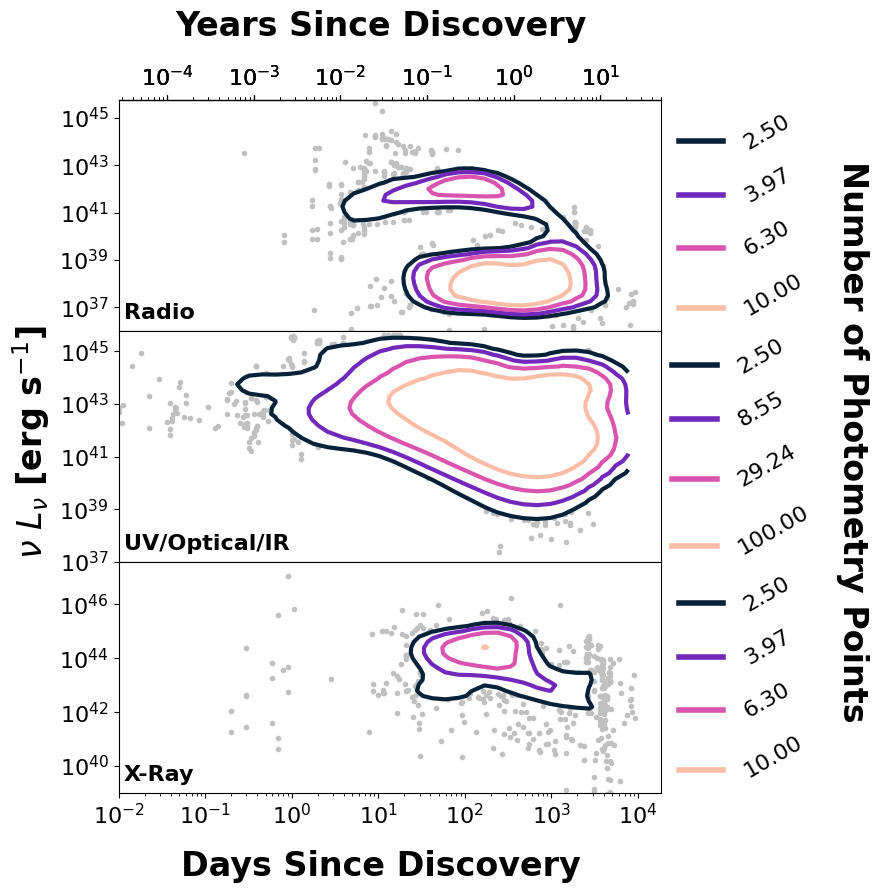

In [11]:
# Create a colormap with only white
white_cmap = ListedColormap(['white'])

p = convphot[~convphot.upperlimit.astype(bool)]

fig, axs = plt.subplots(
    3,1,
    figsize=(7,9), 
    sharex=True, 
    gridspec_kw = {'wspace':0, 'hspace':0},
    # layout="tight"
)

ylims = [(1e36, 1e46), (1e37, 1e46), (1e39, 1e47)]
obs_types = ["radio", "uvoir", "xray"]
obs_type_labels = {
    "radio" : "Radio",
    "uvoir" : "UV/Optical/IR",
    "xray"  : "X-Ray"
}

yr = 365
xlim = (1e-2, 30*yr)
nbins = 40

all_dts = []

cmap = cmr.bubblegum

tick_color = "k" #cmr.dusk.colors[256 - (256//10)] #"peru"#"chocolate"

cmap.set_bad(color=cmap.colors[0])

plot_2dhist = False

for ylim, obs_type, ax in zip(ylims, obs_types, axs.flatten()):

    ax.yaxis.set_minor_locator(mpl.ticker.AutoMinorLocator())
    ax.spines['bottom'].set_color(tick_color)
    ax.spines['top'].set_color(tick_color) 
    ax.spines['right'].set_color(tick_color)
    ax.spines['left'].set_color(tick_color)
    ax.tick_params(axis='x', colors=tick_color, which="both", labelcolor="k")
    ax.tick_params(axis='y', colors=tick_color, which="both", labelcolor="k")
    
    grp = convphot[convphot.obs_type == obs_type]

    days, lum = [], []
    for (filt, targ), phot in grp.groupby(["filter_name", "name"]):
        if targ not in disc_date_dict: continue
        disc_date = disc_date_dict[targ]
        
        phot = phot.sort_values("converted_date")
        phot['mjd_norm'] = (phot.converted_date - disc_date)

        phot = phot[phot.mjd_norm > xlim[0]] # only plot photometry after discovery, otherwise the plot makes no sense

        # uncomment to plot each light curve as a black line:
        #ax.plot(phot.mjd_norm, phot.nu_lum_nu, color='k', alpha=0.05)
        
        days += phot.mjd_norm.to_list()
        lum += phot.nu_lum_nu.to_list()

        #x.set_ylabel(r"$\nu~L_\nu$ [erg s$^{-1}$]")

    ax.plot(days, lum, marker='o', markersize=3, alpha=1, color='silver', linestyle="none", zorder=0)
    
    xbins = np.logspace(np.log10(xlim[0]), np.log10(xlim[1]), nbins+1) # #np.linspace(xlim[0], xlim[1], nbins+1),
    ybins = np.logspace(np.log10(ylim[0]), np.log10(ylim[1]), nbins+1)
    
    heatmap, xedges, yedges = np.histogram2d(
        days, 
        lum, 
        bins=[xbins, ybins],
    )

    dx = np.diff(xedges)
    dy = np.diff(yedges)
    area = np.outer(dx, dy)
    
    ax.set_yscale("log")
    ax.set_xscale("log")
    # # heatmap[heatmap == 0] = 1e-20
    x,y = np.meshgrid(xedges[:-1], yedges[:-1])
    z = heatmap.T #(heatmap / dx[:, np.newaxis]).T #heatmap.T/np.diff(xedges) #heatmap.T,
    z[z==0] = np.min(z[z!=0])/10

    # do some smoothing of the contours
    z1 = scipy.ndimage.gaussian_filter(z, sigma=1.5, order=0)

    minlogz = np.log10(2.5) #0 # np.floor(np.min(np.log10(z)))
    maxlogz = np.ceil(np.max(np.log10(z))/2)
    levs = np.logspace(minlogz, maxlogz, 4)
    levs_wht = deepcopy(levs)
    levs_wht[-1] = 10**(maxlogz*2)
        
    cm = ax.contourf(
        x, y, z1,
        origin='lower', 
        cmap=white_cmap,
        norm = mpl.colors.LogNorm(),
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        levels = levs_wht,
        zorder=0.5
    )

    cm = ax.contour(
        x, y, z1,
        origin='lower', 
        cmap=cmap,
        norm = mpl.colors.LogNorm(),
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        levels = levs,
        zorder=100,
        linewidths= 3
    )

    if plot_2dhist:
        ax.pcolormesh(
            x, 
            y, 
            np.ma.masked_where(heatmap.T < (10**maxlogz)/3, heatmap.T),
            zorder = 20,
            cmap = "binary",
            # norm = mpl.colors.LogNorm()#mpl.colors.Normalize(4, 10**maxlogz),
            edgecolor="none",
            # alpha = 0.8
        )
    
    cbar = fig.colorbar(cm, ax=ax, shrink=0.8, pad=0.02)
    #cbar_labels = [v.get_text() for v in cbar.ax.get_yticklabels()]
    cbar_labels = [f"{v:.2f}" for v in levs]
    #cbar_labels[0] = "$\\mathdefault{\\leq}$"+cbar_labels[0]#.replace("$\\mathdefault{", )
    # cbar.ax.set_yticklabels(cbar_labels)
    cbar_linecolors = cbar.lines[0].get_color()
    legend = ax.legend(
        [mpl.lines.Line2D([0],[0],color=c, lw=4) for c in cbar_linecolors],
        cbar_labels,
        loc="center",
        bbox_to_anchor=(1.15, 0.5),
        frameon=False,
        fontsize=16,
    )
    for text in legend.get_texts():
        text.set_rotation(30) # Rotate by 90 degrees
    cbar.remove()
    
    # print(heatmap.T)
    ax.text(
        0.01, 0.05, 
        obs_type_labels[obs_type], 
        horizontalalignment="left", 
        transform=ax.transAxes, 
        color="k",
        fontsize = 16,
        zorder = 1_000,
        weight = "semibold"
    )
    
    #ax.set_ylim(*ylim)
    all_dts.append(days)

    ax2 = axs[0].secondary_xaxis("top", functions=(lambda x: x/yr, lambda x: x*yr))
    ax2.tick_params(axis='x', colors=tick_color, which="both", labelcolor="k", labelsize=16)

    ax.tick_params(axis='x', labelsize=16)      # x-axis tick labels
    ax.tick_params(axis='y', labelsize=16)      # y-axis tick labels


label_kwargs = dict(
    fontsize = 24,
    weight = "semibold",
)
fig.supxlabel("Days Since Discovery", **label_kwargs)
fig.supylabel(r"$\nu~L_\nu$ [erg s$^{-1}$]", **label_kwargs, x=-0.03)
fig.suptitle("Years Since Discovery", **label_kwargs)
fig.text(1.15, 0.5, "Number of Photometry Points", rotation=-90, va="center", **label_kwargs)

savefig(fig, "tde-lightcurves.png") 

### Figure 10: Photometry Point Wavelength Distribution

In [12]:
# get all of the photometry in otter
with warnings.catch_warnings(action="ignore"):
    allphot = db.get_phot(flux_unit="erg/s/cm^2/Hz", return_type="pandas")

RX J1420+53 has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/NaN.
2017bcc has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/NaN.
RBS 1032 has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/NaN.
2022arb has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/

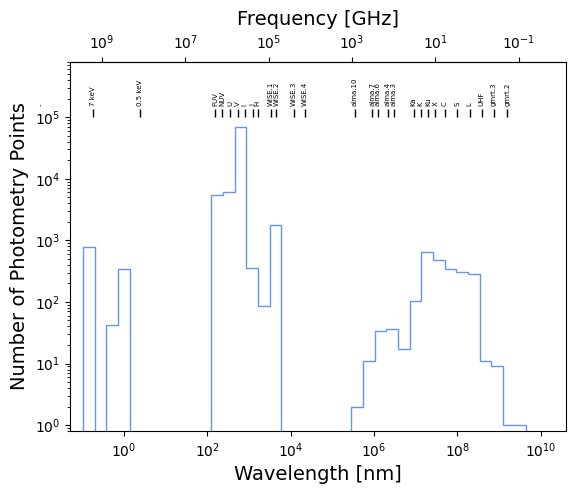

In [13]:
fig, ax = plt.subplots()

f = allphot.converted_wave

logbins = np.logspace(np.log10(f.min()),np.log10(f.max()),40)
bins, edges = np.histogram(f, bins=logbins)

ax.stairs(bins, edges, color='cornflowerblue')

ax.set_xscale("log")
ax.set_yscale("log")

ax.tick_params(axis='x', top=False)

ax.set_xlabel("Wavelength [nm]", fontsize=14)
ax.set_ylabel("Number of Photometry Points", fontsize=14)

# create a dictionary of reference filters/bands to plot
filts = {
    "-":1e-2, # this is just to fix a bug in matplotlib
    #"0.5-1.2 keV" : ((c.h*c.c) / ((1.2-0.5)/2*u.keV)).to(u.m).value,
    #"1.2-2 keV" : ((c.h*c.c) / ((2-1.2)/2*u.keV)).to(u.m).value, 
    # '2-7 keV' : ((c.c * c.h) / ((7-2)/2 * u.keV)).to(u.m).value, 
    "7 keV" : ((c.h*c.c) / (7*u.keV)).to(u.nm).value,
    "0.5 keV" : ((c.h*c.c) / (0.5*u.keV)).to(u.nm).value,
    "FUV": 153.8620701901866,#*1e-9,
    "NUV": 231.56631043707714,#*1e-9,
    # "UVW2": 207.98754332676123*1e-9,
    "U": 353.10502283105023,#*1e-9,
    #"B": 443.0539845758355*1e-9,
    "V": 553.7155963302753,#*1e-9,
    # "G": 673.5412573108297*1e-9,
    #"R": 646.9439215118385*1e-9,
    "I": 788.558706467662,#*1e-9,
    "J": 1255.0918319447906,#*1e-9,
    "H": 1630.5155019191195,#*1e-9,
    # "K": 2157.3600605745955*1e-9,
    "WISE.1": (3.4*u.um).to(u.nm).value,
    "WISE.2": (4.6*u.um).to(u.nm).value,
    "WISE.3":(12*u.um).to(u.nm).value,
    "WISE.4": (22*u.um).to(u.nm).value,
} | {
    k:(
        (v[0] + ((v[1] - v[0]) / 2))*u.GHz
    ).to(
        u.nm, 
        equivalencies=u.spectral()
    ).value 
    for k, v in otter.util.RADIO_BAND_MAPPING.items() 
    if k not in {"alma.1", "alma.9", "alma.5", "alma.8", "VHF", "HF"}
}

ytext = 1.5e5
for lab, xtext in filts.items():
    ax.text(xtext, ytext, lab, horizontalalignment="center", verticalalignment="bottom", rotation=90, fontsize=5)
    ax.vlines(xtext, ymin=ytext/1.5, ymax=ytext/1.1, lw=1, color="k")
    
ax.set_xlim(5e-2, 4e10)
ax.set_ylim(0.8, 8e5)

ax.secondary_xaxis(
    "top", 
    functions=(
        lambda x: (x*u.nm).to(u.GHz, equivalencies=u.spectral()).value, 
        lambda x: (x*u.GHz).to(u.nm, equivalencies=u.spectral()).value
    )
)
ax.set_title("Frequency [GHz]", fontsize=14)

savefig(fig, "photometry-histogram.png")

### Figure 11: Number of Observations as a function of year
This is similar to Figure 7 but instead of discovery date it's just the observation date of the photometry point stored in OTTER

In [14]:
# get all of the photometry in otter
with warnings.catch_warnings(action="ignore"):
    allphot = db.get_phot(flux_unit="erg/s/cm^2/Hz", return_type="pandas")

RX J1420+53 has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/NaN.
2017bcc has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/NaN.
RBS 1032 has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/NaN.
2022arb has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/

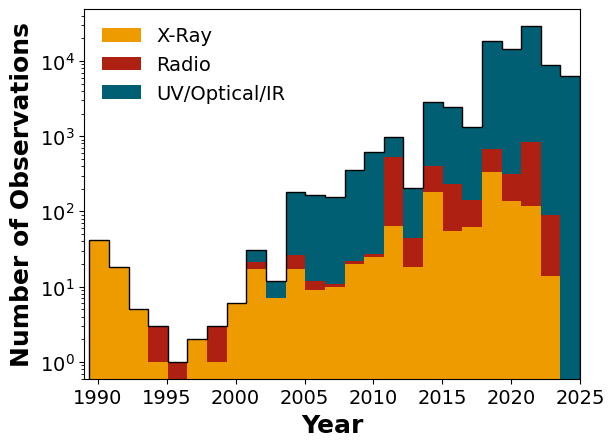

In [15]:
allphot['obs_year'] = np.floor(Time(allphot.converted_date, format='mjd').decimalyear).astype(int)

cs = [ "#EE9B00", "#AE2012", "#005F73"]

allphot.obs_type = allphot.obs_type.replace('radio', 'Radio')
allphot.obs_type = allphot.obs_type.replace('xray', 'X-Ray')
allphot.obs_type = allphot.obs_type.replace('uvoir', 'UV/Optical/IR')

fig, ax = plt.subplots()

n = 40
bottom = np.zeros(n)

all_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
grped_yrs = {y : g.obs_year.values for y,g in allphot.groupby('obs_type')}
labels = ["X-Ray", "Radio", "UV/Optical/IR"]
years = [grped_yrs[lb] for lb in labels]

ax.hist(years, label=labels, bins=n, stacked=True, color=cs)
ax.hist(allphot.obs_year, bins=n, stacked=True, histtype='step', edgecolor='k')

ax.set_yscale('log')

ax.set_ylabel('Number of Observations', fontsize=18, fontweight="semibold")
ax.set_xlabel('Year', fontsize=18, fontweight="semibold")

ax.set_xlim(1989, 2025)

ax.tick_params(axis='x', labelsize=14)      # x-axis tick labels
ax.tick_params(axis='y', labelsize=14)      # y-axis tick labels

ax.legend(fontsize=14, frameon=False)

savefig(fig, "tde-observations-vs-time.png")

## Section 5: Example Analyses

### Section 5.1: Time Delay Analysis

First, we need to import `rpy2` which allows us to call R functions in python. This is necessary because the survival analysis statistical tools are well developed in R and not python (like Kaplan-Meier estimators and Greenwood Confidence).

To use `rpy2` 

1. you need to install R: https://www.r-project.org/
2. And then install rpy2: https://rpy2.github.io/

In [16]:
import rpy2
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import NA_Real, FloatVector, Formula, pandas2ri

/home/nfranz/research/astro-otter/paper/rpy2-env/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "LD_LIBRARY_PATH" redefined by R and overriding existing variable. Current: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server", R: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server"
  warnings.warn(
/home/nfranz/research/astro-otter/paper/rpy2-env/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_LIBS_SITE" redefined by R and overriding existing variable. Current: "/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library:/usr/lib/R/site-library:/usr/lib/R/library", R: "/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library:/usr/lib/R/site-library:/usr/lib/R/library:/usr/lib/R/library:/usr/

Now we need to define a function to do the "survival analysis" (or the statistical analysis that takes the limits into account) 

In [17]:
def surv_analysis(left_censored, right_censored, verbose=True):
    """
    This uses rpy2 to perform a survival analysis on differenced data that has both 
    right and left censored values. It returns the results of a Kaplan-Meier fit 
    and the corresponding quantiles
    """

    # lc = FloatVector([NA_Real if v else d for v, d in zip(left_censored, diff)])
    # rc = FloatVector([NA_Real if v else d for v, d in zip(right_censored, diff)])

    lc = FloatVector(left_censored)
    rc = FloatVector(right_censored)
    
    if verbose:
        print(tuple(lc), tuple(rc))
    
    rsurvival = importr("survival")
    r_surv_obj = rsurvival.Surv(lc, rc, type="interval2")
    
    ro.globalenv["r_surv_obj"] = r_surv_obj
    fit = ro.r("survfit(r_surv_obj ~ 1, conf.int=0.95, conf.type='plain')")

    ro.globalenv["fit"] = fit

    if verbose:
        print(ro.r("summary(fit)"))
    #ro.r("plot(fit)")
    # extract the results of the fit
    res = dict(fit.items())
    if verbose:
        print(str(res['call']))
    resdf = pd.read_csv(io.StringIO(str(res['call'])), skiprows=2, sep='\s+')

    # compute the quantiles
    ro.globalenv["fit"] = fit
    q = pd.read_csv(io.StringIO(str(ro.r("quantile(fit, prob=c(0.16, 0.25, 0.5, 0.75, 0.84))$quantile"))), sep="\s+")
    
    return resdf, q

<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:36: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_30837/2718474138.py:32: SyntaxWarning: invalid escape sequence '\s'
  resdf = pd.read_csv(io.StringIO(str(res['call'])), skiprows=2, sep='\s+')
/tmp/ipykernel_30837/2718474138.py:36: SyntaxWarning: invalid escape sequence '\s'
  q = pd.read_csv(io.StringIO(str(ro.r("quantile(fit, prob=c(0.16, 0.25, 0.5, 0.75, 0.84))$quantile"))), sep="\s+")


Now get the X-ray and UV/Optical/IR photometry

In [18]:
xrays = db.get_phot(obs_type="xray", flux_unit="erg s^-1 cm^-2", return_type="pandas")
uvoir = db.get_phot(obs_type="uvoir", flux_unit="Jy", return_type="pandas")

RX J1420+53 has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/NaN.
Removing 28 photometry points from
                    2017bcc because we can't convert them from ct ->
                    erg s^-1 cm^-2
Unable to apply the source mapping because Cannot set a DataFrame with multiple columns to the single column human_readable_refs
RBS 1032 has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/NaN.
WTP14adbwvs has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_hos

51
Missing discovery date for WTP14acnjbu!
Missing discovery date for WTP16aaqrcr!
Missing discovery date for WTP17aamoxe!
Missing discovery date for WTP17aaldjb!
Missing discovery date for WTP15acbuuv!
Insufficient data for PS1-11af, skipping...
Insufficient data for PTF09ge, skipping...
Insufficient data for ASASSN-15lh, skipping...
Missing discovery date for WTP15acbgpn!
Insufficient data for D1-9, skipping...
Insufficient data for 2016fnl, skipping...
Missing discovery date for WTP17aamzew!
Missing discovery date for AT2022mim!
Missing discovery date for WTP14adbwvs!
Insufficient data for 2018gn, skipping...
Missing discovery date for WTP17aanbso!
Insufficient data for ASASSN-14ae, skipping...
Insufficient data for PTF09djl, skipping...
Missing discovery date for WTP17aalzpx!
Insufficient data for TDE2, skipping...
Insufficient data for D23H-1, skipping...
Missing discovery date for WTP15abymdq!
Missing discovery date for WTP16aatsnw!
Missing discovery date for WTP14adeqka!
Missing

R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :  
R callback write-console: 
   
R callback write-console:  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages
  


Call: survfit(formula = r_surv_obj ~ 1, conf.int = 0.95, conf.type = "plain")

   time n.risk  n.event survival std.err lower 95% CI upper 95% CI
   3.26  20.00 5.39e+00    0.731 0.15612       0.3117        1.000
  10.72  14.61 6.18e-03    0.730 0.15603       0.3115        1.000
  22.00  14.61 4.93e+00    0.484 0.09719       0.0896        0.877
  60.78   9.67 1.67e+00    0.400 0.07197       0.0474        0.753
 144.70   8.00 6.32e-09    0.400 0.07197       0.0474        0.753
 195.73   8.00 1.50e+00    0.325 0.05179       0.0127        0.637
 220.21   6.50 1.50e+00    0.250 0.03412       0.0000        0.517
 227.62   5.00 1.50e+00    0.175 0.01921       0.0000        0.390
 282.55   3.50 1.50e+00    0.100 0.00754       0.0000        0.248
 406.26   1.00 7.06e-15    0.100 0.00754       0.0000        0.248

Call: survfit(formula = r_surv_obj ~ 1, conf.int = 0.95, conf.type = "plain")

      n events median 0.95LCL 0.95UCL
[1,] 20     18     22    3.26     228


##########################

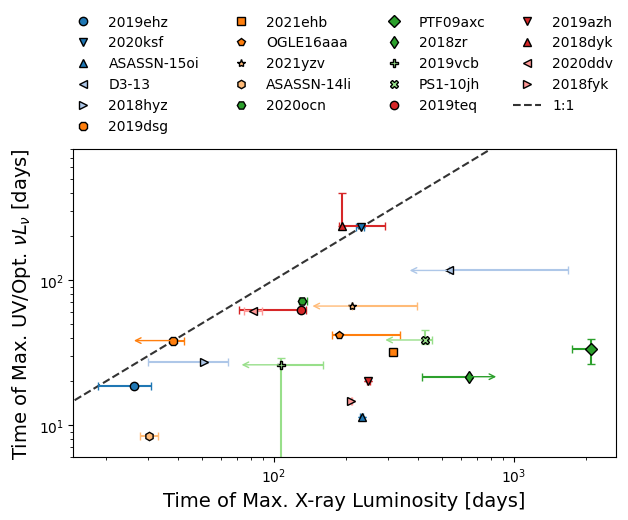

In [19]:
n_tdes = len(list(set(xrays.name.unique()) & set(uvoir.name.unique())))
print(n_tdes)
cmap = mpl.colormaps['tab20']
colors_init = iter(cmap(np.linspace(0, 1, n_tdes)))
markers = list(Line2D.filled_markers)
markers.remove('.')
markers = iter(4*list(markers))

fs = 14

fig, ax = plt.subplots(figsize=(7,4))

max_xray_date = []
max_uvoir_date = []
labels = []
colors = []
markers_used = []
diff = []
left_censored = []
right_censored = []

exclude = {
    "CSS100217", # this is likely not a TDE
    "Sw J1644+57", # we only want to do this for non-jetted events
    "Swift J2058.4+0516", # we only want to do this for non-jetted events
    "Gaia 16aax", # only one post-discovery X-ray observation
}

xray_flux_diffs = []
uvoir_flux_diffs = []

for name in list(set(xrays.name.unique()) & set(uvoir.name.unique())):

    if name in exclude: continue
    
    t = db.get_meta(names=name)[0]
    try:
        disc_date = t.get_discovery_date().mjd
    except:
        print(f"Missing discovery date for {name}!")
        continue
    
    uvoir_data = uvoir[(uvoir.name == name) * (~uvoir.upperlimit) * (uvoir.converted_date > disc_date) * (uvoir.converted_wave < 1_000)].sort_values(by="converted_date")
    xray_data = xrays[(xrays.name == name) * (~xrays.upperlimit) * (xrays.converted_date > disc_date)].sort_values(by="converted_date")

    if len(uvoir_data) == 0 or len(xray_data) == 0:
        print(f"Insufficient data for {name}, skipping...")
        continue

    color = next(colors_init)
    mark = next(markers)

    try:
        z = t.get_redshift()
    except:
        print("Missing redshift for {name}!")
        continue

    lum_dist = cosmo.luminosity_distance(z)
    
    uvoir_lum = (4*np.pi*lum_dist**2 * (uvoir_data.converted_flux.values*u.Jy) * uvoir_data.converted_freq.values*u.GHz).to(u.erg/u.s).value
    xray_lum = (4*np.pi*lum_dist**2 * (xray_data.converted_flux.values*u.erg/u.s/u.cm**2)).to(u.erg/u.s).value
    
    max_uvoir_idx = np.argmax(uvoir_lum)
    max_xray_idx = np.argmax(xray_lum)
    
    max_uvoir_dt = uvoir_data.converted_date.values[max_uvoir_idx] - disc_date
    max_xray_dt = xray_data.converted_date.values[max_xray_idx] - disc_date
    
    # determine which are limits
    uvoir_uplim, uvoir_lolim, xray_uplim, xray_lolim = False, False, False, False
    if max_uvoir_idx == 0:
        ax.annotate("", xy=(max_xray_dt, max_uvoir_dt-max_uvoir_dt/3), xytext=(max_xray_dt, max_uvoir_dt), arrowprops=dict(arrowstyle="->", color=color))
            
    if max_uvoir_idx == len(uvoir_data)-1:
        ax.annotate("", xy=(max_xray_dt, max_uvoir_dt+max_uvoir_dt/3), xytext=(max_xray_dt, max_uvoir_dt), arrowprops=dict(arrowstyle="->", color=color))
        
    if max_xray_idx == 0:
        ax.annotate("", xy=(max_xray_dt-max_xray_dt/3, max_uvoir_dt), xytext=(max_xray_dt, max_uvoir_dt), arrowprops=dict(arrowstyle="->", color=color))

    if max_xray_idx == len(xray_data)-1:
        ax.annotate("", xy=(max_xray_dt+max_xray_dt/3, max_uvoir_dt), xytext=(max_xray_dt, max_uvoir_dt), arrowprops=dict(arrowstyle="->", color=color))
    
    has_lim = (max_uvoir_idx == 0 or max_uvoir_idx == len(uvoir_data)-1 or max_xray_idx == 0 or max_xray_idx == len(xray_data)-1)

    xray_is_uplim = max_xray_idx == 0
    xray_is_lolim = max_xray_idx == len(xray_data)-1
    uvoir_is_uplim = max_uvoir_idx == 0
    uvoir_is_lolim = max_uvoir_idx == len(uvoir_data)-1

    xray_min = xray_data.converted_date.values[max_xray_idx-1] - disc_date if not xray_is_uplim else -np.inf
    xray_max = xray_data.converted_date.values[max_xray_idx+1] - disc_date if not xray_is_lolim else np.inf 
    uvoir_min = uvoir_data.converted_date.values[max_uvoir_idx-1] - disc_date if not uvoir_is_uplim else -np.inf
    uvoir_max = uvoir_data.converted_date.values[max_uvoir_idx+1] - disc_date if not uvoir_is_lolim else np.inf
    alldiffs = [xray_min-uvoir_min, xray_max-uvoir_min, xray_min-uvoir_max, xray_max-uvoir_max]

    loval,upval = min(alldiffs), max(alldiffs)
    
    if not xray_is_uplim:
        f1 = xray_data.converted_flux.values[max_xray_idx-1]
        f1_unc = xray_data.converted_flux_err.values[max_xray_idx-1]
        f2 = xray_data.converted_flux.values[max_xray_idx]
        f2_unc = xray_data.converted_flux_err.values[max_xray_idx]
        xray_sigma_sigma = (f2 - f1) / np.sqrt(f1_unc**2 + f2_unc**2)
        xray_flux_diffs.append(
            xray_sigma_sigma
        )
    else:
        f1 = xray_data.converted_flux.values[max_xray_idx+1]
        f1_unc = xray_data.converted_flux_err.values[max_xray_idx+1]
        f2 = xray_data.converted_flux.values[max_xray_idx]
        f2_unc = xray_data.converted_flux_err.values[max_xray_idx]
        xray_sigma_sigma = (f2 - f1) / np.sqrt(f1_unc**2 + f2_unc**2)
        xray_flux_diffs.append(
            xray_sigma_sigma
        )

    if not uvoir_is_uplim:
        f1 = uvoir_data.converted_flux.values[max_uvoir_idx-1]
        f1_unc = uvoir_data.converted_flux_err.values[max_uvoir_idx-1]
        f2 = uvoir_data.converted_flux.values[max_uvoir_idx]
        f2_unc = uvoir_data.converted_flux_err.values[max_uvoir_idx]
        uvoir_sigma_sigma = (f2 - f1) / np.sqrt(f1_unc**2 + f2_unc**2)
        uvoir_flux_diffs.append(
            uvoir_sigma_sigma
        )
    else:
        f1 = uvoir_data.converted_flux.values[max_uvoir_idx+1]
        f1_unc = uvoir_data.converted_flux_err.values[max_uvoir_idx+1]
        f2 = uvoir_data.converted_flux.values[max_uvoir_idx]
        f2_unc = uvoir_data.converted_flux_err.values[max_uvoir_idx]
        uvoir_sigma_sigma = (f2 - f1) / np.sqrt(f1_unc**2 + f2_unc**2)
        uvoir_flux_diffs.append(
            uvoir_sigma_sigma
        )

    max_uvoir_date.append(max_uvoir_dt)
    max_xray_date.append(max_xray_dt)
    
    diff.append(max_xray_dt-max_uvoir_dt)
    left_censored.append(NA_Real if xray_is_uplim or uvoir_is_lolim else loval)
    right_censored.append(NA_Real if xray_is_lolim or uvoir_is_uplim else upval)
    
    labels.append(name)
    colors.append(color)
    markers_used.append(mark)
    
    ax.errorbar(
        [max_xray_dt], [max_uvoir_dt], 
        marker=mark, 
        color=color, 
        xerr=(
            [0] if xray_is_uplim else [max_xray_dt-xray_min], 
            [0] if xray_is_lolim else [xray_max-max_xray_dt]
        ), 
        yerr=(
            [0] if uvoir_is_uplim else [max_uvoir_dt-uvoir_min], 
            [0] if uvoir_is_lolim else [uvoir_max-max_uvoir_dt]
        ), 
        mec="k",
        linestyle="none",
        capsize=3
    )

diff = np.array(diff)
left_censored = np.array(left_censored)
right_censored = np.array(right_censored)

ax.legend(
    handles = [Line2D([0], [0], marker=m, color=c, label=name,
        markersize=6, linestyle="none", markeredgecolor="k") for c,name,m in zip(colors, labels, markers_used)] + [Line2D([0],[0], marker="none", color="k", label="1:1", linestyle="--", alpha=0.8)],
    loc = "lower left",
    bbox_to_anchor = (-0.03, 1.01),
    fontsize=10,
    ncols=4,
    fancybox=False,
    frameon=False,
    facecolor="w",
    framealpha=0.8
)

xy = np.linspace(0,2000)
ax.plot(xy,xy, linestyle="--", color="k", zorder=0, alpha=0.8)

ax.set_ylim(6e0, 8e2)

ax.set_yscale("log")
ax.set_xscale("log")

ax.set_ylabel(r"Time of Max. UV/Opt. $\nu L_\nu$ [days]", fontsize=fs)
ax.set_xlabel(r"Time of Max. X-ray Luminosity [days]", fontsize=fs)

savefig(fig, "max-uvoir-vs-max-xray.png")

resdf, quan = surv_analysis(list(left_censored), list(right_censored))
print()
print("###############################################################")
print("Median w/ Greenwood Confidence Levels:\n", resdf)
lo, lo25, med, up75, up = quan.T[0].values
print()
print("Quantiles of the Kaplan-Meier CDF:\n", quan)
print("###############################################################")

max_diff_df = pd.DataFrame({
    "name": labels,
    "diff": diff,
    "max_uvoir_dates": max_uvoir_date,
    "max_xray_dates":max_xray_date
}).sort_values(by="diff")

We now need to find the distribution of the first obesrvations

In [20]:
names = []
colors = []
first_uvoir_obs = []
first_xray_obs = []

for name, color, mark in zip(list(set(xrays.name.unique()) & set(uvoir.name.unique())), colors_init, markers):
    
    t = db.get_meta(names=name)[0]
    try:
        disc_date = t.get_discovery_date().mjd
    except:
        print(f"Missing discovery date for {name}!")
        continue
    
    uvoir_data = uvoir[(uvoir.name == name)* (uvoir.converted_date > disc_date)].sort_values(by="converted_date")
    xray_data = xrays[(xrays.name == name)* (xrays.converted_date > disc_date)].sort_values(by="converted_date")

    if len(uvoir_data) == 0 or len(xray_data) == 0:
        print(f"Insufficient data for {name}, skipping...")
        continue

    first_uvoir_obs.append(uvoir_data.iloc[0].converted_date - disc_date)
    first_xray_obs.append(xray_data.iloc[0].converted_date - disc_date)
    
    names.append(name)
    colors.append(color)

first_obs_df = pd.DataFrame({
    "name" : names,
    "first_uvoir_obs": first_uvoir_obs,
    "first_xray_obs": first_xray_obs
})

Missing discovery date for WTP14acnjbu!
Missing discovery date for WTP16aaqrcr!
Missing discovery date for WTP17aamoxe!
Missing discovery date for WTP17aaldjb!
Missing discovery date for WTP15acbuuv!
Insufficient data for PS1-11af, skipping...
Missing discovery date for WTP15acbgpn!
Missing discovery date for WTP17aamzew!
Missing discovery date for AT2022mim!
Missing discovery date for WTP14adbwvs!
Missing discovery date for WTP17aanbso!


We can now merge these dataframes for creating the figure comparing the two distributions

In [21]:
alltimes = pd.merge(max_diff_df, first_obs_df, how="outer", on="name")

alltimes.sort_values("diff")

,name,diff,max_uvoir_dates,max_xray_dates,first_uvoir_obs,first_xray_obs
1,2018dyk,-45.130147,236.500884,191.370736,NaN,NaN
12,2020ksf,-0.001030,231.315771,231.314741,18.169056,16.575000
7,2019dsg,0.001964,38.207431,38.209395,0.464907,38.209395
8,2019ehz,7.716357,18.531036,26.247392,0.010185,18.531959
11,2020ddv,21.018945,60.875991,81.894936,NaN,NaN
17,ASASSN-14li,21.639733,8.459027,30.098760,8.454234,8.481709
4,2018hyz,24.134167,27.238365,51.372532,0.480410,29.876202
13,2020ocn,58.783199,71.684473,130.467672,0.253495,57.502479
9,2019teq,66.868941,62.367184,129.236125,NaN,NaN
10,2019vcb,81.224087,25.999456,107.223543,NaN,NaN


R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :  
R callback write-console: 
   
R callback write-console:  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages
  


(-0.0036702939978567883, -11.994122355303261, 217.2471669548977, nan, 2.637582697898324, nan, 277.4337409630025, 132.00724400000036, nan, 19.367340796299686, 55.89299720599956, 1698.0039039999974, 391.1165777720016, nan, nan, 9.25480888189486, 223.7857064560012, -212.31564399049967, 14.278353847199469, 194.91548891320417) (12.185895000002347, 7.038658547498926, 223.16599999999744, 1564.5708060000034, 37.944422834443685, 3.877359361096751, 287.6586619873051, 294.30390000000625, 328.3842430000004, 24.635232328699203, 65.65740801688662, nan, nan, 157.399936439484, 421.39382399999886, 74.06622221529688, 231.4583406515958, 54.084927472504205, 28.257683756906772, 196.54873378130287)
Call: survfit(formula = r_surv_obj ~ 1, conf.int = 0.95, conf.type = "plain")

   time n.risk  n.event survival std.err lower 95% CI upper 95% CI
   3.26  20.00 5.39e+00    0.731 0.15612       0.3117        1.000
  10.72  14.61 6.18e-03    0.730 0.15603       0.3115        1.000
  22.00  14.61 4.93e+00    0.484 0

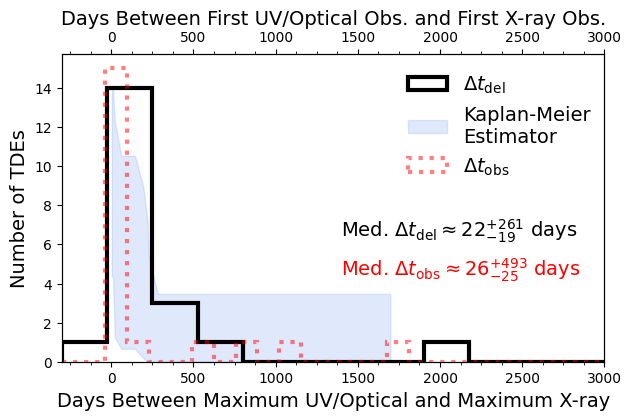

In [22]:
fig, ax = plt.subplots(figsize=(7,4))
xrange = (-300, 3000)

# Add minor ticks to the main axis
ax.xaxis.set_minor_locator(AutoMinorLocator(4))  # 2 minor ticks between each major


counts, bins, _ = ax.hist(diff, edgecolor="k", facecolor=(0,0,0,0), bins=12, label=r"$\Delta t_{\rm del}$", zorder=100, histtype="step", lw=3, range=xrange)
ax.set_xlabel("Days Between Maximum UV/Optical and Maximum X-ray", fontsize=fs)

resdf, quan = surv_analysis(list(left_censored), list(right_censored))
print()
print("###############################################################")
print("Median w/ Greenwood Confidence Levels:\n", resdf)
lo, lo25, med, up75, up = quan.T[0].values
print()
print("Quantiles of the Kaplan-Meier CDF:\n", quan)
print("###############################################################")
#ax.axvline(med, color="r", linestyle=":")
#ax.axvspan(lo, up, color="r", alpha=0.2)
ax.text(1400, 6, fr"Med. $\Delta t_{{\rm del}} \approx {med:.0f}^{{+{up-med:.0f}}}_{{-{med-lo:.0f}}}$ days", rotation=0, color="k", verticalalignment="bottom", ha="left", fontsize=fs)
ax.set_ylabel("Number of TDEs", fontsize=fs)
ax.set_xlim(*xrange)

# add the Kaplan-Meier Estimator fit to the distribution
surv_prob, time, upper, lower = ro.globalenv["fit"].rx2("surv"), ro.globalenv["fit"].rx2("time"), ro.globalenv["fit"].rx2("upper"), ro.globalenv["fit"].rx2("lower")
#ax.plot(time, surv_prob*max(counts), color="cornflowerblue", linestyle="-")
ax.fill_between(time, lower*max(counts), upper*max(counts), alpha=0.2, color="cornflowerblue", label="Kaplan-Meier\nEstimator")

twinax = ax.twiny()
twinax.hist(
    (alltimes["first_xray_obs"] - alltimes["first_uvoir_obs"]).dropna(),
    bins=25,
    edgecolor="red",
    color = "w",
    alpha=0.5,
    fc=(0, 0, 0, 0),
    label = r"$\Delta t_{\rm obs}$",
    zorder = 0,
    histtype="step",
    linestyle=":",
    lw = 3,
    range=xrange
)

lo, med, up = np.quantile((alltimes["first_xray_obs"] - alltimes["first_uvoir_obs"]).dropna(), [0.16, 0.5, 0.84])
ax.text(1400, 4, fr"Med. $\Delta t_{{\rm obs}} \approx {med:.0f}^{{+{up-med:.0f}}}_{{-{med-lo:.0f}}}$ days", rotation=0, color="red", verticalalignment="bottom", ha="left", fontsize=fs)

# twinax.set_xlim(ax.get_xlim())
# twinax.set_xticks(ax.get_xticks())
twinax.set_xlim(*xrange)
twinax.set_xlabel("Days Between First UV/Optical Obs. and First X-ray Obs.", fontsize=fs)
twinax.xaxis.set_minor_locator(AutoMinorLocator(4))  # 2 minor ticks between each major

fig.legend(loc="center", bbox_to_anchor=(0.75, 0.7), frameon=False, fontsize=14)

savefig(fig, "max-xray-vs-max-uvoir-delay-hist.png")

### Example 2: ECLE Analysis

We've made a directory called `ecle-data` that has CSVs in the OTTER format (see the [interfacing with private data tutorial](./private_data.ipynb)). This dataset has the radio data in it.

The first thing we need to do is read that data into the `Otter` object using the `Otter.from_csvs` method.

In [23]:
db = otter.Otter.from_csvs(
    metafile="ecle-data/ecle-metadata.csv", 
    photfile="ecle-data/all-photometry.csv", 
    local_outpath="ecle-data/private-data"
)

/home/nfranz/research/astro-otter/otter/src/otter/io/otter.py:900: DtypeWarning: Columns (5,13,14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  phot_unclean = pd.read_csv(photfile)
/home/nfranz/research/astro-otter/otter/src/otter/io/otter.py:1242: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  p[k].fillna("null", inplace=True)
/home/nfranz/research/astro-otter/otter/src/otter/io/otter.py:1242: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained a

Attempting to login to https://otter.idies.jhu.edu/api with the following credentials:
username: user-guest
password: test
2019qiz
Found this object in the database already, merging the data...
AT2017gge
Found this object in the database already, merging the data...
AT2018bcb
Found this object in the database already, merging the data...
AT2018dyk
Found this object in the database already, merging the data...
AT2020vdq
Found this object in the database already, merging the data...
AT2021acak
Found this object in the database already, merging the data...
AT2021dms
Found this object in the database already, merging the data...
AT2021qth
Found this object in the database already, merging the data...
AT2022fpx
Found this object in the database already, merging the data...
AT2022upj
Found this object in the database already, merging the data...
SDSS_J0748
Found this object in the database already, merging the data...
SDSS_J0807
Found this object in the database already, merging the data...


Now that we have the radio data we can query for all of the transients in OTTER (including the private ones). We also want to read in the metadata file so we know which events are ECLEs.

In [24]:
all_transients = db.query(query_private=True)
meta = pd.read_csv("ecle-data/ecle-metadata.csv")

Names have the same score! Just using the existing default_name


Finally, we can iterate through these transients, query WISE, and find both the maximum IR color and radio luminosity.

2022arb has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/NaN.
2021blz has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/NaN.
Unable to apply the source mapping because 'private'
VAST J221936.0+004724 has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/NaN.
Unable to apply the source mapping because "['2014ApJ...780...44C', '2020SSRv..216...81A']"


multiple cntr:
[71133301351020297, 71133301351020298]
Skipping VAST J221936.0+004724 because no redshift!


ARP 299-B AT1 has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/NaN.
Unable to apply the source mapping because "['2011ApJ...732L..12B', '2020SSRv..216...81A']"
Unable to apply the source mapping because "['2013ApJ...763...84B', '2020SSRv..216...81A']"
2022adm has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/NaN.
Unable to apply the source mapping because "['2013A&A...552A...5V', '2020SSRv..216...81A']"
Unable to apply the source mapping because "['2019A&A...630A..98S', '2020SSRv..216...81A']"
XMMSL2 J144605.0+685735 has at least one photometry point where it is unclear if a host subtraction was performed. This can be

Skipping VAST J234449.6+015434 because no redshift!


VAST J210626.2-020055 has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/NaN.
Unable to apply the source mapping because "['2014ApJ...793...38A', '2020SSRv..216...81A']"


...

Skipping VAST J213437.8-620433 because no redshift!


2019gte has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/NaN.
VAST J230053.0-020732 has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/NaN.
AT2021qth has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/NaN.
SDSS_J0807 has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column

multiple cntr:
[1966001601351030620, 1966001601351030621]
Skipping VAST J230053.0-020732 because no redshift!
AT2021qth has radio photometry but no good wise photometry!


SDSS_J1247 has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/NaN.
SDSS_J2220 has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/NaN.
SDSS_J1402 has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/NaN.
SDSS_J1241 has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is nul

[False False False False  True False False False False False False False
 False  True False False False False False False False False False False
 False False False False False False  True False False False False False
 False False False False False False False False False False  True  True
 False False False False False False False False False False False False
 False  True False False False False  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True]


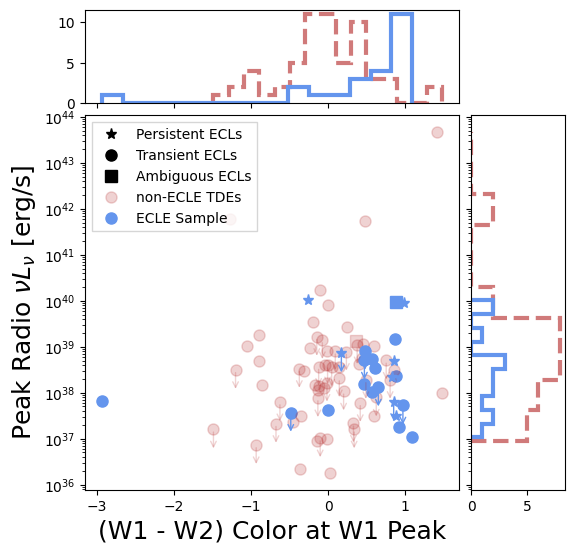

In [25]:
fig = plt.figure(figsize=(6,6))
gs = fig.add_gridspec(2, 2,  width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.05, hspace=0.05)

ax = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)

cmap = mpl.colormaps['plasma']

ecle_names = set(meta.name.unique())
n_ecle = len(meta)
colors = cmap(np.linspace(0, 1, n_ecle))
i = 0

radio_filts = ("L", "S", "C")
tdes_to_label = {"AT2019dsg", "AT2016ezh"}

radio_data, wise_data, class_ = [], [], []
cbar_labels = []

uplim_filter = []

for t in all_transients:
    try:
        phot = t.clean_photometry(flux_unit="mJy", obs_type="radio")
    except otter.exceptions.FailedQueryError:
        continue # this just means no radio photometry
    
    # query wise
    coord = t.get_skycoord()
    data_finder = otter.DataFinder(
        coord.ra.value, 
        coord.dec.value, 
        coord.ra.unit,
        coord.dec.unit,
        name = t.default_name
    )
    wise_phot = data_finder.query_wise(overwrite=False)
    
    if len(wise_phot) == 0:
        print(t.default_name, "has radio photometry but no good wise photometry!")
        continue
    
    keep_keys = ["filter", "flux", "flux_err", "date_mjd", "upperlimit"]
    w1 = wise_phot[wise_phot["filter"] == "w1"][keep_keys]
    w2 = wise_phot[wise_phot["filter"] == "w2"][keep_keys]
    
    w1_w2 = w1.merge(w2, on="date_mjd", suffixes=("_w1", "_w2")).dropna()
    
    wise_max = np.argmin(w1_w2.flux_w1) # choose peak W1
    wise_color = w1_w2.flux_w1.tolist()[wise_max] - w1_w2.flux_w2.tolist()[wise_max]
    wise_uplim = w1_w2.upperlimit_w1.values[wise_max] or w1_w2.upperlimit_w2.values[wise_max]
    
    # get the luminosity
    try:
        z = t.get_redshift() * cu.redshift
    except:
        print(f"Skipping {t.default_name} because no redshift!")
    lum_dist = z.to(u.Mpc, equivalencies=cu.redshift_distance(cosmo, kind="luminosity"))
    phot["lum_nu"] = [4*np.pi*lum_dist**2 * (val * u.mJy) for val in phot.converted_flux]
    phot["lum"] = [(val*eff*u.GHz).to(u.erg/u.s).value for val, eff in zip(phot.lum_nu, phot.converted_freq)]
    
    # get the discovery date
    try:
        disc_date = t.get_discovery_date().mjd
    except:
        continue
    
    aliases = [n["value"] for n in t["name"]["alias"]]
    isECLE = any(a in ecle_names for a in aliases)
    
    if isECLE:
        for a in aliases:
            if a in ecle_names:
                metadata = meta[a == meta.name]
                break
        classification = metadata.classification.values[0]
        
        color = colors[i]
        i += 1
        
        # All of the ECLEs have S-band data
        s = phot[phot.filter_name.isin(radio_filts)]
        cbar_labels.append(metadata.name.values[0].replace("_", ""))
        
        alpha = 1

        color = "cornflowerblue"
        
    else:
        s = phot[phot.filter_name.isin(radio_filts)]
        if len(s) == 0: continue
        classification = t.get_classification()[0]
        color = 'firebrick'
        alpha = 0.2
    
    if classification == "TDE":
        symb = "o"
    elif classification == "AGN":
        symb = "*"
    else:
        symb = "s"
    
    if np.all(s.upperlimit):
        max_idx = np.argmin(s.lum.values) # we want the MOST CONSTRAINING upperlimit
        toplot = s
        uplim_filter.append(True)
    else:
        toplot = s[~s.upperlimit]
        max_idx = np.argmax(toplot.lum.values)
        uplim_filter.append(False)
        
    y = toplot.lum.values[max_idx]
    x = wise_color
    
    radio_data.append(y)
    wise_data.append(x)
    class_.append(isECLE)
    
    ax.plot(x, y, color=color, marker=symb, alpha=alpha, markersize=8)
    
    if toplot.upperlimit.values[max_idx]:
        ax.annotate("", xy=(x, y/3), xytext=(x, y), arrowprops=dict(arrowstyle='->',color=color,alpha=alpha))

    if wise_uplim:
        ax.annotate("", xy=(y, x/3), xytext=(y, x), arrowprops=dict(arrowstyle='->',color=color,alpha=alpha))

radio_data, wise_data, ecle_filt, uplim_filt = np.array(radio_data), np.array(wise_data), np.array(class_), np.array(uplim_filter)
print(ecle_filt)
        
custom_legend_params = dict(
    lw = 4,
    markersize = 8,
    linestyle = "none"
)
        
custom_lines = [
    Line2D([0], [0], marker="*", color="k", **custom_legend_params),
    Line2D([0], [0], marker="o", color="k", **custom_legend_params),
    Line2D([0], [0], marker="s", color="k", **custom_legend_params),
    Line2D([0], [0], marker="o", alpha=0.2, **custom_legend_params, color="firebrick"),
    Line2D([0], [0], marker="o", alpha=1, **custom_legend_params, color="cornflowerblue")
]

custom_labels = ["Persistent ECLs", "Transient ECLs", "Ambiguous ECLs", "non-ECLE TDEs", "ECLE Sample"]
        
ax.set_yscale("log")

ax.legend(custom_lines, custom_labels, loc="upper left", ncols=1, fontsize=10, frameon=True, fancybox=False)

ax.set_ylabel(r"Peak Radio $\nu L_\nu$ [erg/s]", fontsize=18)
ax.set_xlabel("(W1 - W2) Color at W1 Peak", fontsize=18)

# plot the side histograms
nbins=15
wise_ecle_bins, wise_ecle_edges = np.histogram(wise_data[ecle_filt],bins=nbins)
wise_data_bins, wise_data_edges = np.histogram(wise_data[~ecle_filt],bins=nbins)
ax_histx.stairs(wise_data_bins, wise_data_edges, color='firebrick', linestyle='--', alpha=0.6, lw=3)
ax_histx.stairs(wise_ecle_bins, wise_ecle_edges, color='cornflowerblue', linestyle='-', alpha=1, lw=3)

nbins = 10
hist, bins = np.histogram(radio_data[~ecle_filt * ~uplim_filt],bins=nbins)
logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
radio_data_bins, radio_data_edges = np.histogram(radio_data[~ecle_filt * ~uplim_filt],bins=logbins)
ax_histy.stairs(radio_data_bins, radio_data_edges, orientation="horizontal", color='firebrick', linestyle='--', alpha=0.6, lw=3)

hist, bins = np.histogram(radio_data[ecle_filt * ~uplim_filt],bins=nbins)
logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
radio_ecle_bins, radio_ecle_edges = np.histogram(radio_data[ecle_filt * ~uplim_filt],bins=logbins)
ax_histy.stairs(radio_ecle_bins, radio_ecle_edges, orientation="horizontal", color='cornflowerblue', linestyle='-', alpha=1, lw=3)

ax_histx.tick_params(axis="x", labelbottom=False)
ax_histy.tick_params(axis="y", labelleft=False)

savefig(fig, "ecle-radio-vs-wise.png")


### Example 3: MOSFiT Model

This notebook will show you how to generate the plots in the paper from the outputs of MOSFiT. We recommend returning to the [modeling](./modeling.ipynb) notebook to see how to convert the dataset into the MOSFiT input format. This will assume that the MOSFiT inputs and outputs are stored in the `mosfit` directory.

For reference (and reproducability) the bash commands we used to run MOSFiT is

```
args=(
    -e $1 # input file directory
    -c # save the chains
    -o mosfit_output # the directory to save to 
    -m tde # use the tde model
    --local-data-only # dont query OSC for more data
    -N 150 # use 150 walkers
    -i 20000 # run for 20,000 iterations
    -S 600 # use 600 synthetic photometry points between first and last observation
    -x radiusphot temperaturephot luminosities_out dense_times dense_luminosities dmdt times_out # extra outputs
    -E 200 1500
    -qs # quick saving
    -s $2 # the suffix for saving to prevent overwrite
)

mpirun -np 3 mosfit "${args[@]}"
```

First, we need to define a few variables (like the discovery dates).

In [26]:
# _t0 = discovery
# _p = peak date

zso_t0 = 59165.6500579
zso_p = 59184.2
sdu_t0 = 59400.9073264
sdu_p = 59419.36

Now we can plot AT2020zso.

In [27]:
lc = pd.read_csv('mosfit/AT2020zso.csv',sep='\t')
lc['m_ab'] = [-2.5*np.log10((f*1e-3)/3631) for f in lc.f_nu]
lc['m_ab_error'] = [2.5*(df*1e-3)/(f*1e-3*np.log(10)) for f,df in zip(lc.f_nu,lc.e_flux_density)]

df_walkers = pd.read_json('mosfit/AT2020zso_walkers_zso.json')
model = df_walkers.loc['models'][0][0]
photo = df_walkers.loc['photometry'][0]

p = pd.DataFrame(photo)
cols = ['time', 'e_magnitude', 'magnitude', 'band', 'realization']
ncols = ['time', 'e_magnitude', 'magnitude']
p = p[cols]
p[ncols] = p[ncols].apply(pd.to_numeric)
p = p.dropna(subset=['realization'])

/tmp/ipykernel_30837/2010292069.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model = df_walkers.loc['models'][0][0]
/tmp/ipykernel_30837/2010292069.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  photo = df_walkers.loc['photometry'][0]


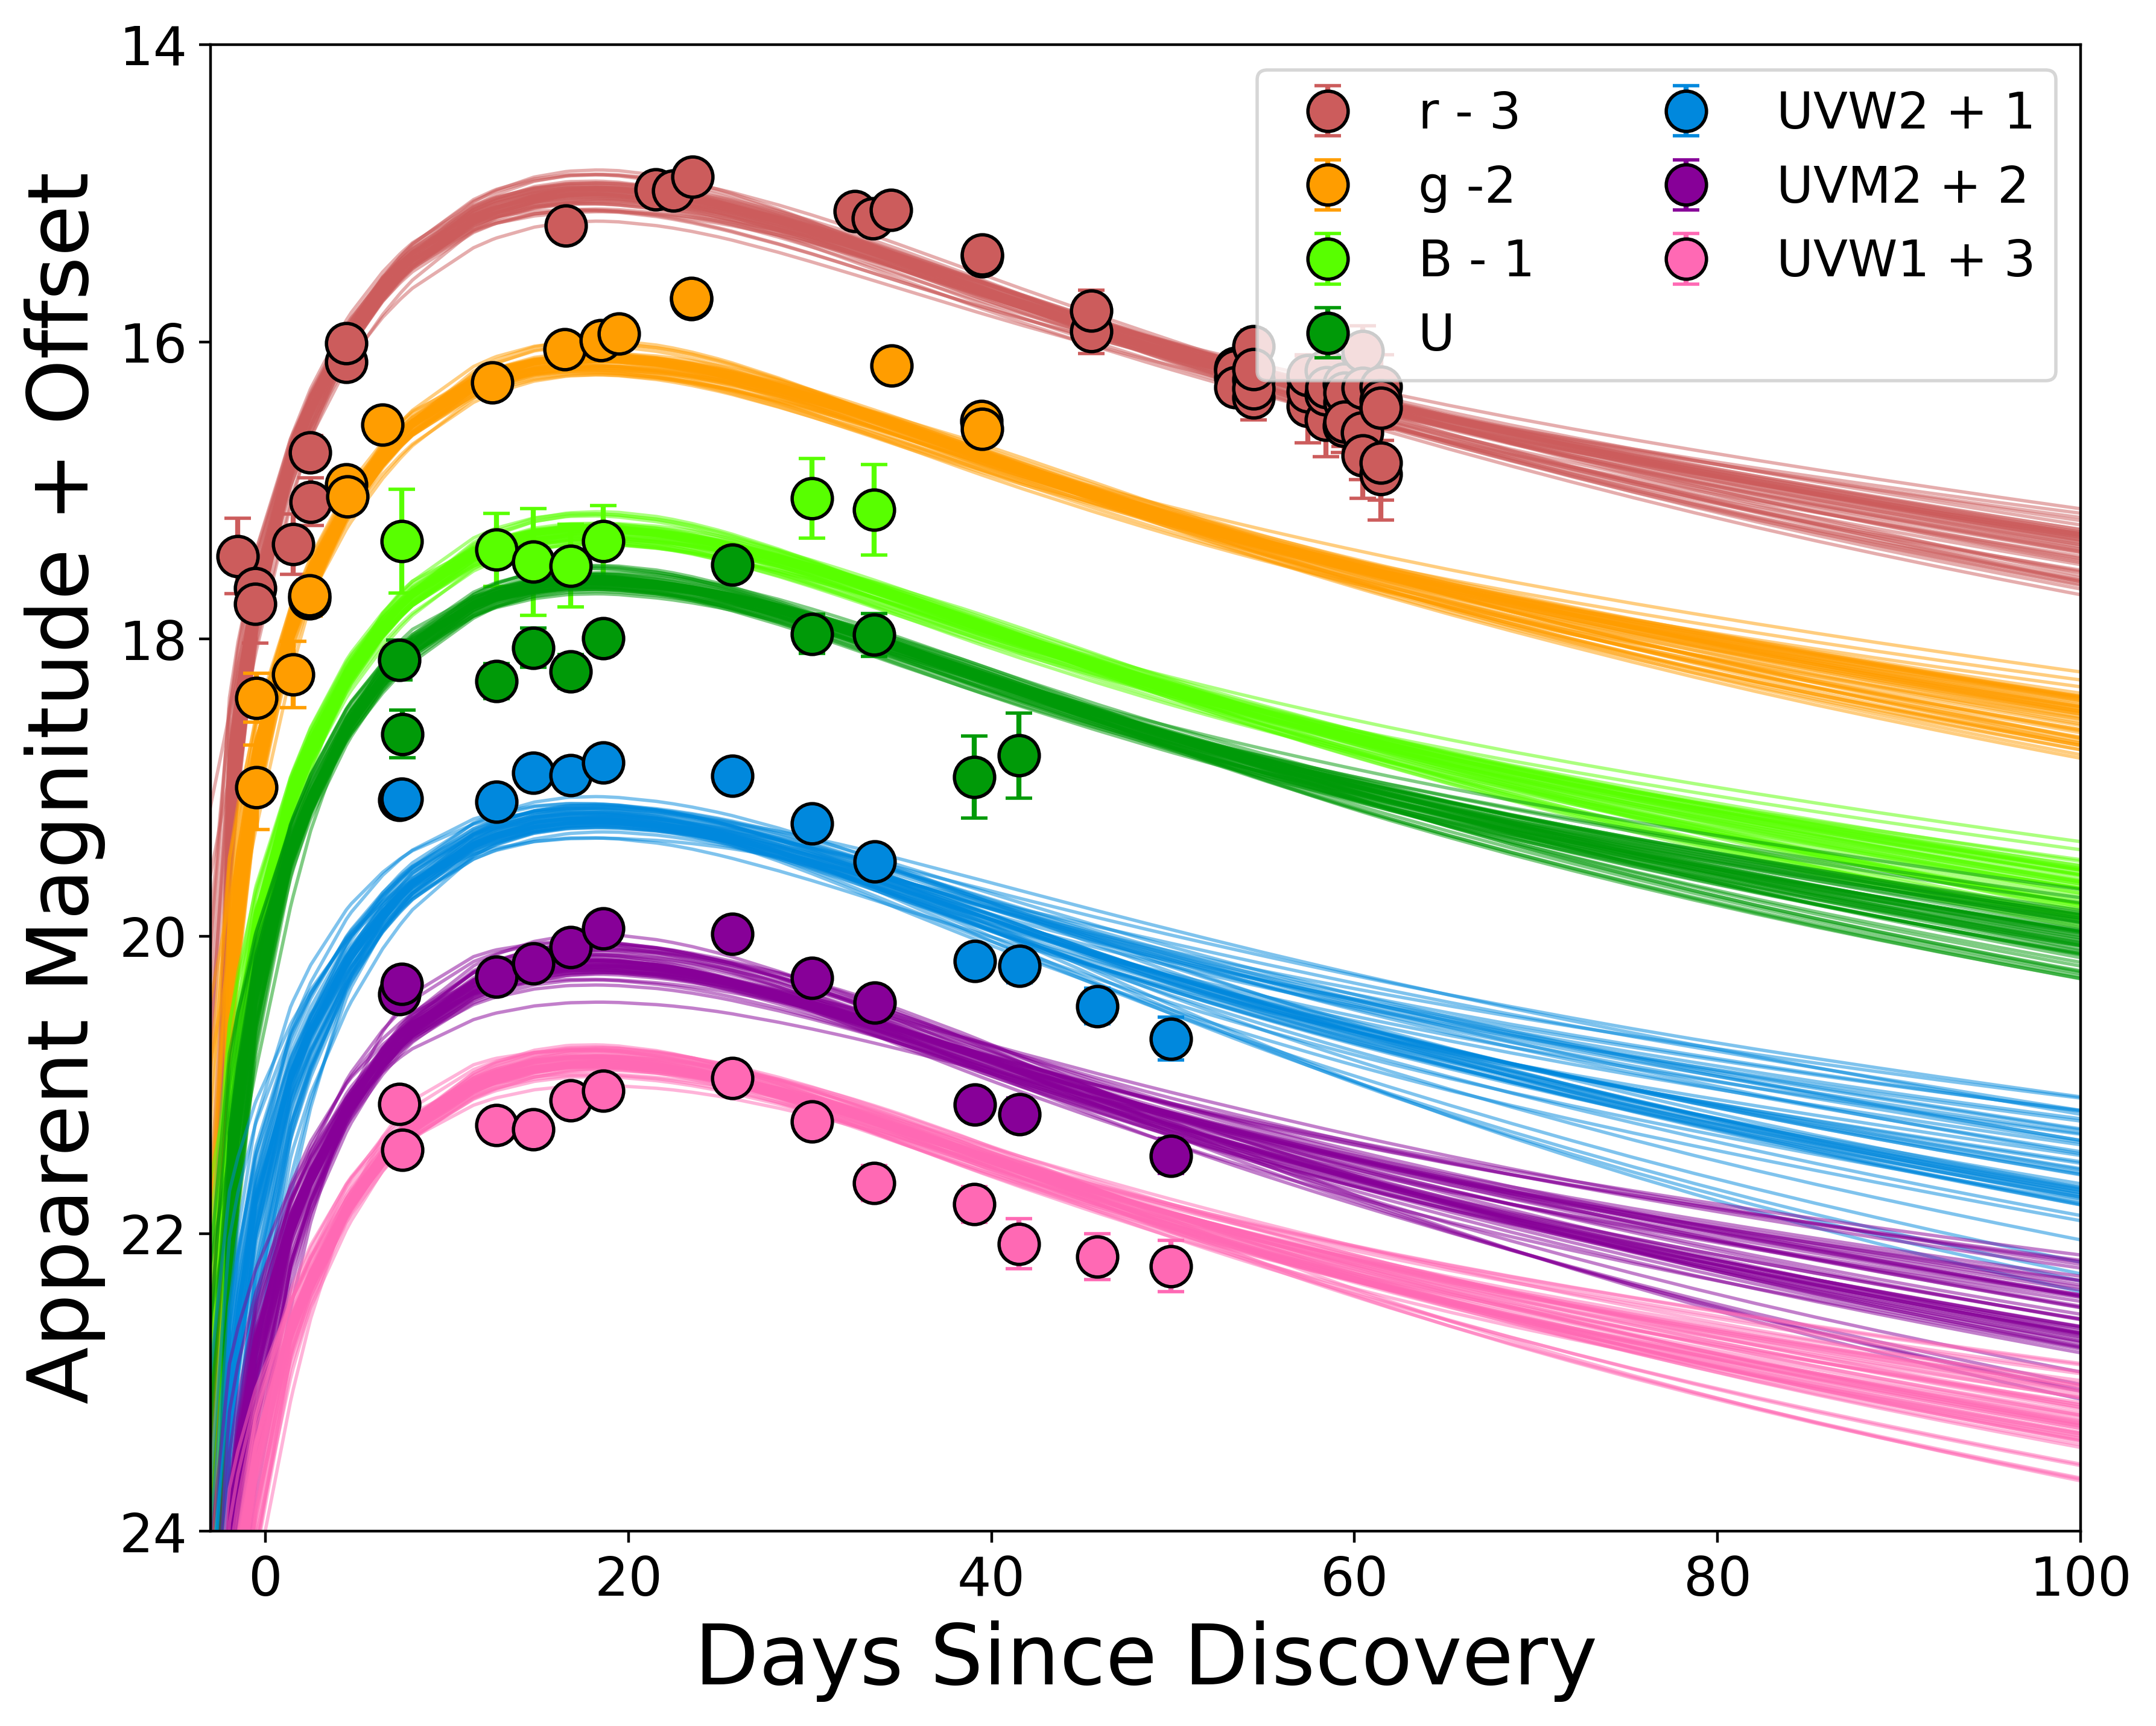

In [28]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 8),dpi=400)
rs = p['realization'].unique()
bs_all = ['r', 'g', 'B', 'U', 'UVW2', 'UVM2', 'UVW1']
c_lst_all = cmr.take_cmap_colors('nipy_spectral_r', 6, cmap_range=(0.03, 0.9), return_fmt='hex')+['hotpink','magenta']
o_lst = [-3, -2, -1, 0,1,2,3,4,5,6]
ol_lst = ['- 3', '-2', '- 1', '','+ 1','+ 2','+ 3','+ 4','+ 5', '+ 6']

bs = [b for b in bs_all if b in p['band'].unique()]
c_lst = [c for c,b in zip(c_lst_all,bs_all) if b in p['band'].unique()]

for i,(b,c,o,ol) in enumerate(zip(bs,c_lst,o_lst,ol_lst)):
    for r in rs[:50]:
        mjd = p[(p['realization']==r) & (p['band']==b)].time-zso_t0
        mag = p[(p['realization']==r) & (p['band']==b)].magnitude
        axes.plot(mjd,o+mag,'-',lw=1,alpha=0.5,color=c)
    axes.errorbar(lc[(lc['band']==b) & (lc['upperlimit']==False)].time-zso_t0,
                 o+lc[(lc['band']==b) & (lc['upperlimit']==False)].m_ab,
                  yerr = lc[(lc['band']==b) & (lc['upperlimit']==False)].m_ab_error,
              fmt='o',color=c,ms=12,label=f'{b} {ol}',mec='k',capsize=4)
    
axes.legend(loc=1,ncol = 2,fontsize = 15,markerscale=1)
axes.set_xlim(-3,100)
axes.set_ylim(24,14)
axes.tick_params(axis='both', labelsize=16) 
axes.set_ylabel('Apparent Magnitude + Offset',fontsize=25)
axes.set_xlabel('Days Since Discovery',fontsize=25)
savefig(fig, "AT2020zso-mosfit-bestfit.png")

And now we can do the same with AT2021sdu.

In [29]:
lc = pd.read_csv('mosfit/AT2021sdu.csv',sep='\t')
lc['m_ab'] = [-2.5*np.log10((f*1e-3)/3631) for f in lc.f_nu]
lc['m_ab_error'] = [2.5*(df*1e-3)/(f*1e-3*np.log(10)) for f,df in zip(lc.f_nu,lc.e_flux_density)]

df_walkers = pd.read_json('mosfit/AT2021sdu_walkers_sdu.json')
model = df_walkers.loc['models'][0][0]
photo = df_walkers.loc['photometry'][0]

p = pd.DataFrame(photo)
cols = ['time', 'e_magnitude', 'magnitude', 'band', 'realization']
ncols = ['time', 'e_magnitude', 'magnitude']
p = p[cols]
p[ncols] = p[ncols].apply(pd.to_numeric)
p = p.dropna(subset=['realization'])

/tmp/ipykernel_30837/3281557049.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model = df_walkers.loc['models'][0][0]
/tmp/ipykernel_30837/3281557049.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  photo = df_walkers.loc['photometry'][0]


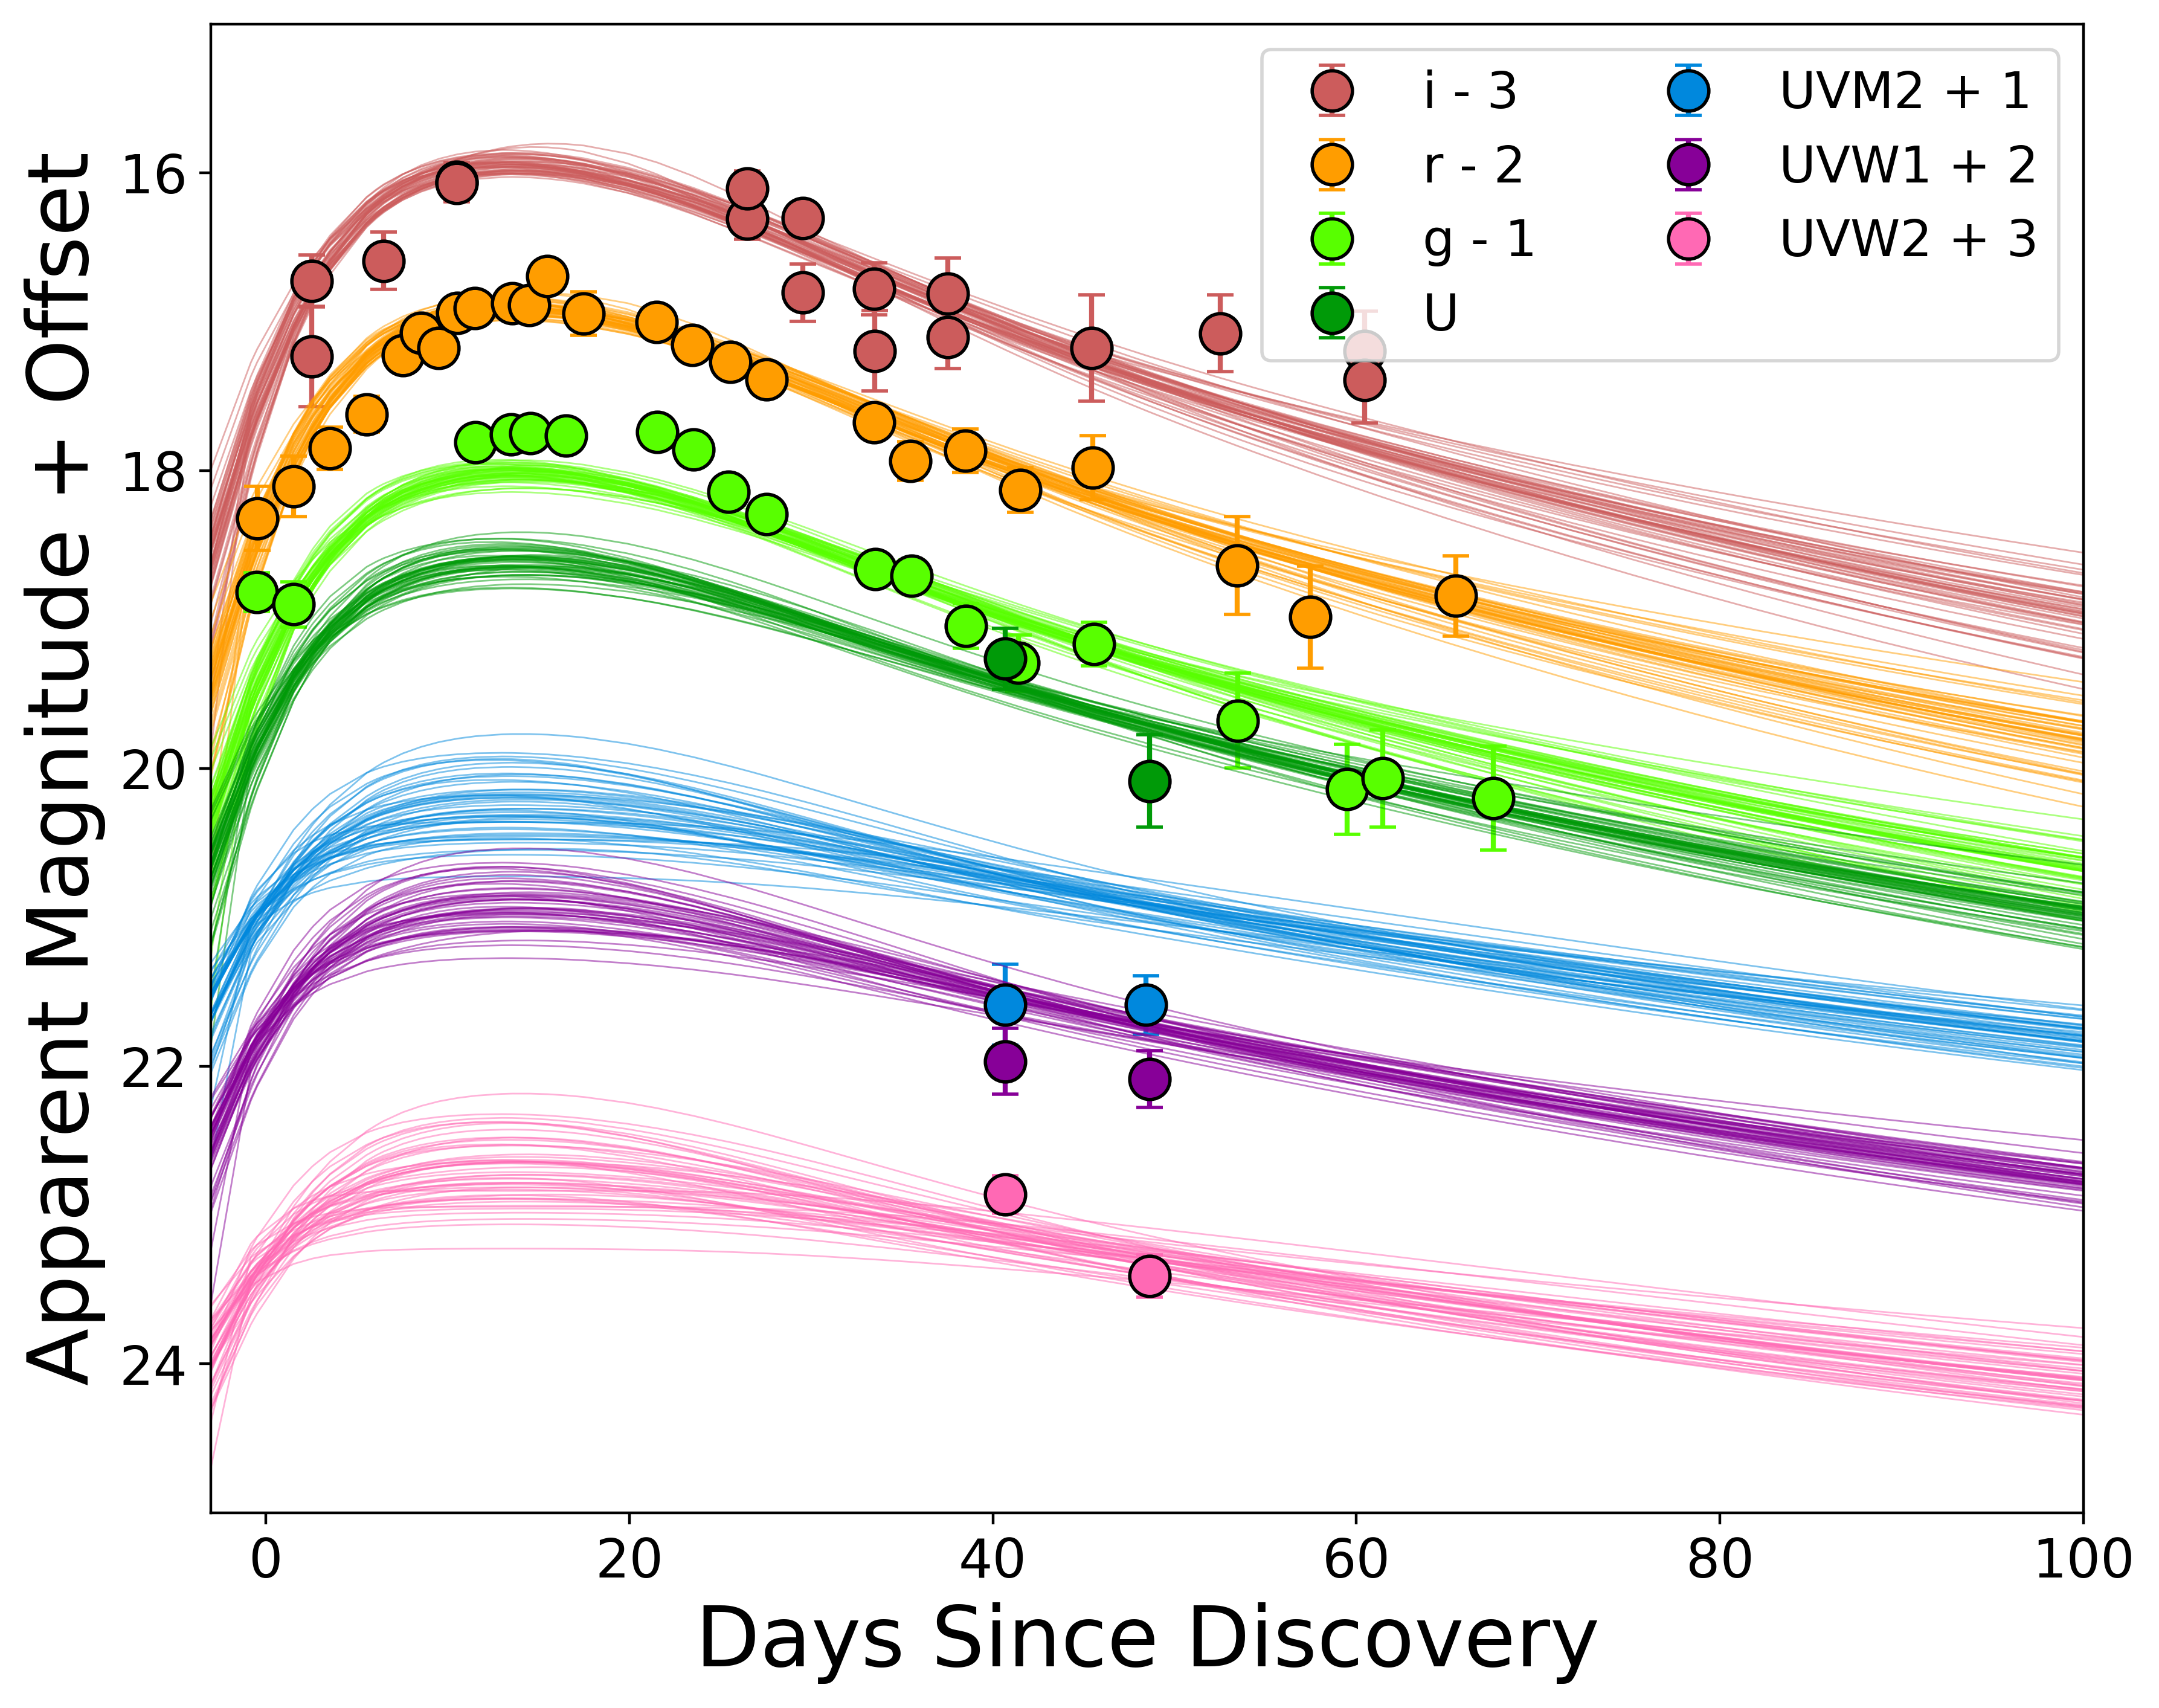

In [30]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 8),dpi=400)
rs = p['realization'].unique()
bs_all = ['i', 'r', 'g', 'U', 'UVM2', 'UVW1', 'UVW2']
c_lst_all = cmr.take_cmap_colors('nipy_spectral_r', 6, cmap_range=(0.03, 0.9), return_fmt='hex')+['hotpink','magenta']
o_lst = [-3, -2, -1, 0,1,2,3,4,5]
ol_lst = ['- 3', '- 2', '- 1', '','+ 1','+ 2','+ 3','+ 4','+ 5', '+ 6']

bs = [b for b in bs_all if b in p['band'].unique()]
c_lst = [c for c,b in zip(c_lst_all,bs_all) if b in p['band'].unique()]


for i,(b,c,o,ol) in enumerate(zip(bs,c_lst,o_lst,ol_lst)):
    for r in rs[:50]:
        mjd = p[(p['realization']==r) & (p['band']==b)].time - sdu_t0
        mag = p[(p['realization']==r) & (p['band']==b)].magnitude
        axes.plot(mjd,o+mag,'-',lw=0.5,alpha=0.5,color=c)
    axes.errorbar(lc[(lc['band']==b) & (lc['upperlimit']==False)].time - sdu_t0,
                 o+lc[(lc['band']==b) & (lc['upperlimit']==False)].m_ab,
                  yerr = lc[(lc['band']==b) & (lc['upperlimit']==False)].m_ab_error,
              fmt='o',color=c,ms=12,label=f'{b} {ol}',mec='k',capsize=4)
    
axes.legend(loc=1,ncol = 2,fontsize = 15,markerscale=1)
axes.set_xlim(-3,100)
axes.set_ylim(25,15)
axes.tick_params(axis='both', labelsize=16) 

axes.set_ylabel('Apparent Magnitude + Offset',fontsize=25)
axes.set_xlabel('Days Since Discovery',fontsize=25)

savefig(fig, "AT2021sdu-mosfit-bestfit.png")

### Example 4: Testing a ML classifier

Similar to Example 3 above, running FLEET is complex and typically done outside a Jupyter notebook. See the FLEET code/documentation for running it yourself. Here, we show how we create the figure in section 5.4 from the FLEET output.

We assume you have run FLEET and saved the output to a file called `OTTER_FLEET.txt`

<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_30837/2752914060.py:16: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("OTTER_FLEET.txt", sep="\s+")


8


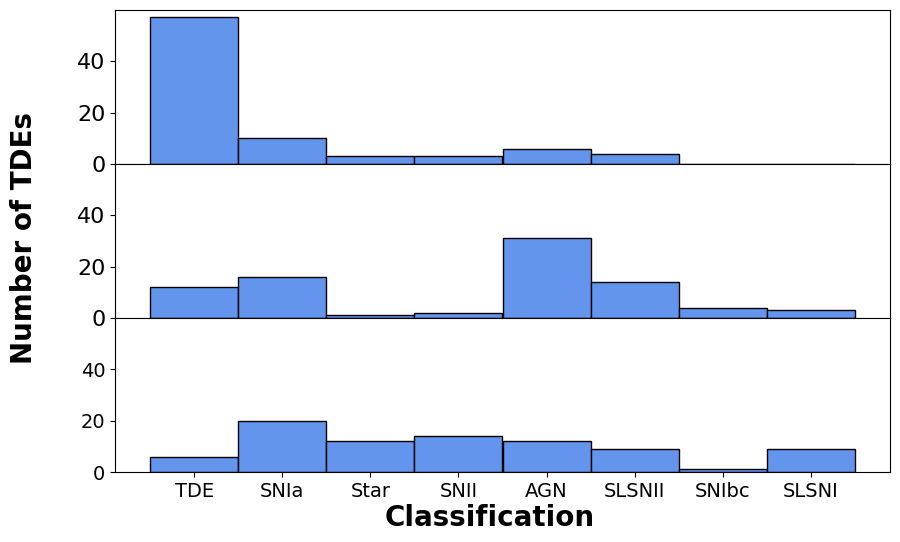

In [31]:
m0 = []
m1 = []
m2 = []

cols = [
    "AGN",
    "SLSNI",
    "SLSNII",
    "SNII",
    "SNIa",
    "SNIbc",
    "Star",
    "TDE"
]

df = pd.read_csv("OTTER_FLEET.txt", sep="\s+")

for _,row in df.iterrows():
    to_sort = row[["P_late_"+c for c in cols]]
    res = to_sort.sort_values(ascending=False)
    res_list = [v.split('_')[-1] for v in list(res.keys())]
    # print(res)
    
    m0.append(res_list[0])
    m1.append(res_list[1])
    m2.append(res_list[2])
    
fig,axs = plt.subplots(3,1,sharex=True, sharey=True, figsize=(10,6))

nbins = max(
    len(np.unique(m0)),
    len(np.unique(m1)),
    len(np.unique(m2)),
    
)
print(nbins)
for ax, m in zip(axs, [m0,m1,m2]):
    ax.hist(m, align="left", ec="k", range=(0,nbins), bins=nbins, fc="cornflowerblue")

    ax.tick_params(axis='both', labelsize=16)

fig.supylabel("Number of TDEs", fontsize=20, fontweight="semibold")
fig.supxlabel("Classification", fontsize=20, fontweight="semibold")

ax.tick_params(axis='both', labelsize=14)

fig.subplots_adjust(wspace=0, hspace=0)

savefig(fig, "fleet-classification-distributions.png")